**ΑΣΚΗΣΗ 1**

In [1]:
import numpy as np
from numpy.random import choice
import matplotlib.pyplot as plt

In [2]:
def rand_walk_Z(start=0, probs=(0.5, 0.5)):
    x = start
    steps = [-1, 1]  # probs order: (left, right)
    while True:
        x += choice(steps, p=probs)
        yield x

In [3]:
a = -70
b = 100
N = 500

# Λίστες για να αποθηκεύσουμε τους χρόνους εξόδου.
escape_times_left = np.zeros(N, dtype=int)
escape_times_right = np.zeros(N, dtype=int)

ΕΡΩΤΗΣΗ 1

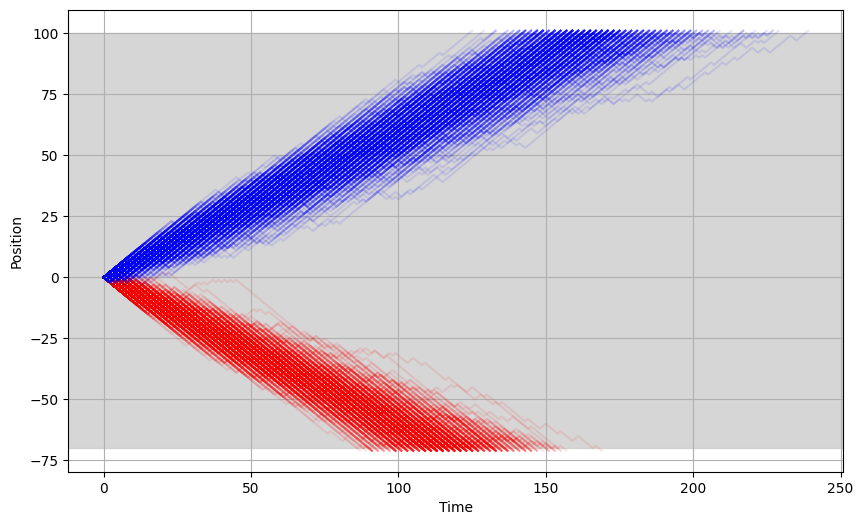

In [21]:
fig1, ax1 = plt.subplots(figsize=(10, 6))
probs_left = (0.8, 0.2)
for i in range(N):
    walker = rand_walk_Z(probs=probs_left)
    x = 0
    chain = [x]
    t = 0
    while a <= x <= b:
        x = next(walker)
        chain.append(x)
        t += 1
    escape_times_left[i] = t

    ax1.plot(chain, color='red', alpha=0.1) #κόκκινο-αριστερά

probs_right = (0.2, 0.8)
for i in range(N):
    walker = rand_walk_Z(probs=probs_right)
    x = 0
    chain = [x]
    t = 0
    while a <= x <= b:
        x = next(walker)
        chain.append(x)
        t += 1
    escape_times_right[i] = t
    ax1.plot(chain, color='blue', alpha=0.1) #μπλέ-δεξιά

    #Μορφοποιούμε το αποτέλεσμα

plt.axhspan(a, b, color='#cccccc', alpha=0.8)
ax1.grid()
plt.xlabel('Time')
plt.ylabel('Position')

plt.show()

Παρατηρούμε ότι οι κόκκινες διαδρομές που έχουν τάση προς τα αριστερά, έχουν καθοδική κλίση και συγκεντρώνονται όλες προς το όριο a=−70. Καμία  δεν φτάνει σχεδόν το 100. Ομοίως, οι μπλε διαδρομές με τάση προς τα δεξιά, έχουν ανοδική κλίση και συγκεντρώνονται στο όριο b=100. Επίσης, αναδεικνύεται  ότι ο κόκκινος rw τερματίζει  πολύ πιο γρήγορα σε σχέση με τον μπλε, κάτι το οποίο είναι λογικό αφού το άνω όριο b = 100, είναι μεγαλύτερο σε απόλυτη τιμή από το a = -70, ενώ η αρχική θέση είναι το 0.

ΕΡΩΤΗΣΗ 2

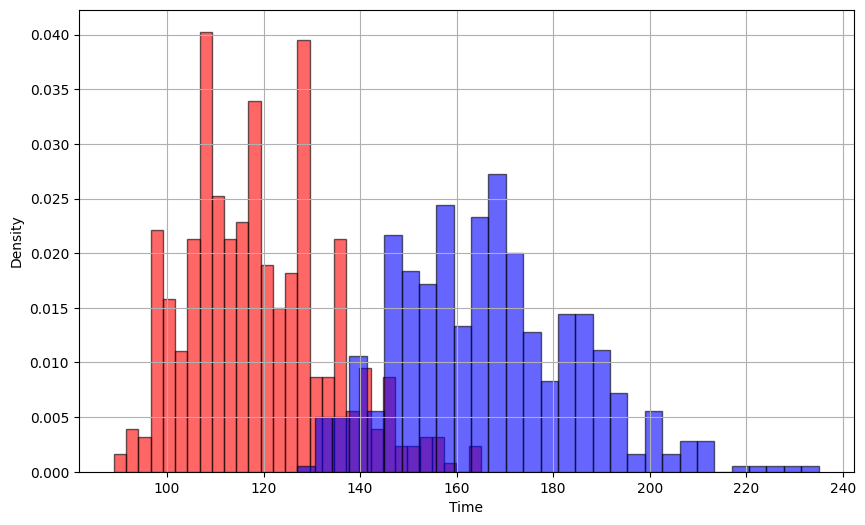

In [20]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

# κάνουμε alpha=0.6 για να φαίνονται οι αλληλοεπικαλύψεις
ax2.hist(escape_times_left, bins=30, edgecolor='black', color='red', alpha=0.6, density=True, label='Left drift')
ax2.hist(escape_times_right, bins=30, edgecolor='black', color='blue', alpha=0.6, density=True, label='Right drift')

ax2.grid()
plt.xlabel('Time')
plt.ylabel('Density')

plt.show()

Παρατηρούμε ότι το  κόκκινο ιστόγραμμα συγκεντρώνεται  σε  μικρότερους χρόνους από το μπλε. Αυτό είναι αναμενόμενο, καθώς  η αρχική μας θέση είναι το 0, με αριστερό όριο το −70, ενώ το δεξί το 100. Ο μπλέ έχει να διανύσει μεγαλύτερη απόσταση από τον κόκκινο με ίδιο drift, οπότε αναμένουμε ο χρόνος διαφυγής να είναι μεγαλύτερος

**ΑΣΚΗΣΗ 2**

Ορίζω συνάρτηση-γεννήτρια για τον Z+.

In [22]:
def rand_walk_Z_plus(start=0):
    x = start
    while True:
        if x == 0:
            step = choice([1, 0], p=[1/3, 2/3])
        else:
            step = choice([1, -1], p=[1/3, 2/3])
        x += step
        yield x

In [38]:
np.random.seed(2017)

N_walks = 1000
total_steps = 1000

# Πίνακες για την αποθήκευση των αποτελεσμάτων
X_100 = np.zeros(N_walks, dtype=int)
M_1000 = np.zeros(N_walks, dtype=int)

In [39]:
for i in range(N_walks):
    walker = rand_walk_Z_plus()
    x = 0
    max_x = 0

    for n in range(1, total_steps + 1):
        x = next(walker)
        if x > max_x:
            max_x = x
        if n == 100:
            X_100[i] = x
    M_1000[i] = max_x

ΕΡΩΤΗΣΗ 1

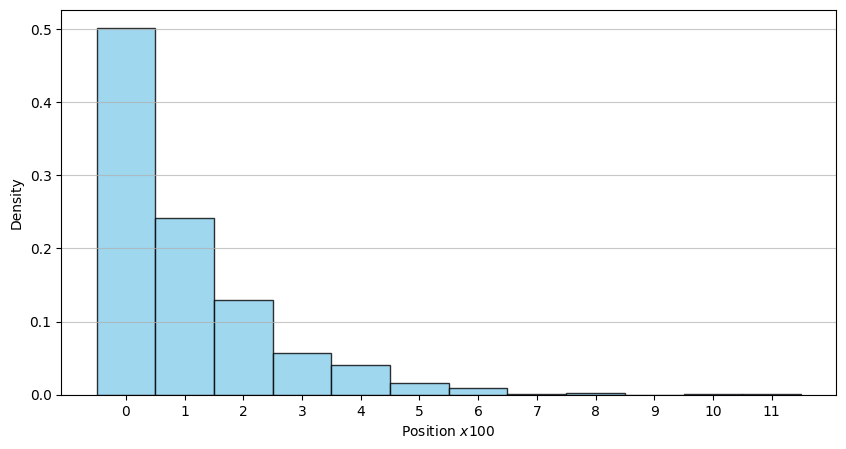

In [40]:
plt.figure(figsize=(10, 5))
bins_X = range(min(X_100), max(X_100) + 2)

plt.hist(X_100, bins=bins_X, edgecolor='black', color='skyblue', density=True, alpha=0.8, align='left')
plt.xlabel('Position $x100$')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.7)
plt.xticks(range(min(X_100), max(X_100) + 1))

plt.show()

Παρατηρούμε πως επειδή η αλυσίδα έχει ισχυρό drift επιστροφής προς την αρχή, το σύστημα συγκλίνει σε μια αναλλοίωτη-στάσιμη κατανομή γύρω από το μηδέν. Πιο συγκεκριμένα, το ιστόγραμμα για τη θέση X_100 δείχνει ότι η πλειοψηφία των αλυσίδων βρίσκεται στο 0, με τις πιθανότητες να πέφτουν εκθετικά όσο απομακρυνόμαστε προς μεγαλύτερους ακέραιους στον Z+.

ΕΡΩΤΗΣΗ 2

Ιστόγραμμα κατανομής M_1000

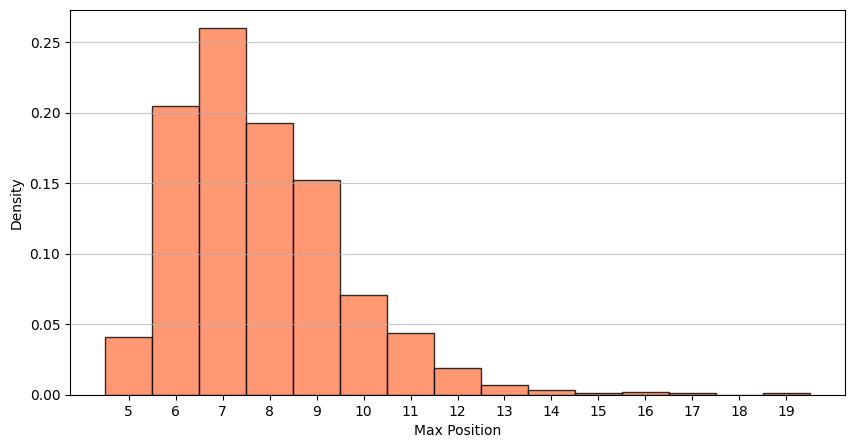

In [41]:
plt.figure(figsize=(10, 5))
bins_M = range(min(M_1000), max(M_1000) + 2)

plt.hist(M_1000, bins=bins_M, edgecolor='black', color='coral', density=True, alpha=0.8, align='left')
plt.xlabel('Max Position')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.7)
plt.xticks(range(min(M_1000), max(M_1000) + 1))

plt.show()

Υπολογίσμός  δειγματικής μέσης τιμής και διασποράς της M_1000

In [36]:
mean_M = np.mean(M_1000)
var_M = np.var(M_1000, ddof=1)

print(f"Δειγματική Μέση Τιμή: {mean_M:.4f}")
print(f"Δειγματική Διασπορά: {var_M:.4f}")

Δειγματική Μέση Τιμή: 7.7650
Δειγματική Διασπορά: 3.4192


Παρατηρούμε  ότι η πιο συχνή μέγιστη θέση  στις 1000 προσομοιώσεις είναι στο 7. Πιο συγκεκριμένα, η κατανομή της Μ_1000 σβήνει σταδιακά προς τα δεξιά. Παρόλο που η ισχυρή τάση της αλυσίδας είναι αριστερή (πιθανότητα 2/3), ο μεγάλος αριθμός βημάτων (1000) δίνει στο σύστημα αρκετές ευκαιρίες να κάνει κάποια σπάνια, συνεχόμενα βήματα προς τα δεξιά. Έτσι, βλέπουμε κάποιες ελάχιστες αλυσίδες να έχουν καταφέρει να φτάσουν μέχρι και τη θέση 19. Τέλος, αποφαίνεται από το διάγραμμα ότι σε 1000 βήματα, η αλυσίδα προλαβαίνει να απομακρυνθεί τουλάχιστον μέχρι το 4 ή 5.

**ΑΣΚΗΣΗ 3**

Ορίζουμε random walk in Z^2 generator

In [42]:
def rand_walk_Z2(start=(0, 0), probs=(0.25, 0.25, 0.25, 0.25)):
    # probs order (left, right, bottom, up)
    x, y = start
    steps = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    while True:
        dx, dy = steps[choice(4, p=probs)]  # choice(4) = choose a number in [0,3]
        x, y = x + dx, y + dy
        yield x, y

In [49]:
np.random.seed(2017)

R_vals = np.arange(10, 110, 10)  # R = 10, 20, 30, ..., 100
N_sims = 500
mean_times = []

In [50]:
for R in R_vals:
    R2 = R**2
    times = np.zeros(N_sims, dtype=int)

    for i in range(N_sims):
        walker = rand_walk_Z2()
        x, y = (0, 0)
        t = 0

        while x**2 + y**2 < R2:
            x, y = next(walker)
            t += 1

        times[i] = t
    mean_t = np.mean(times)
    mean_times.append(mean_t)

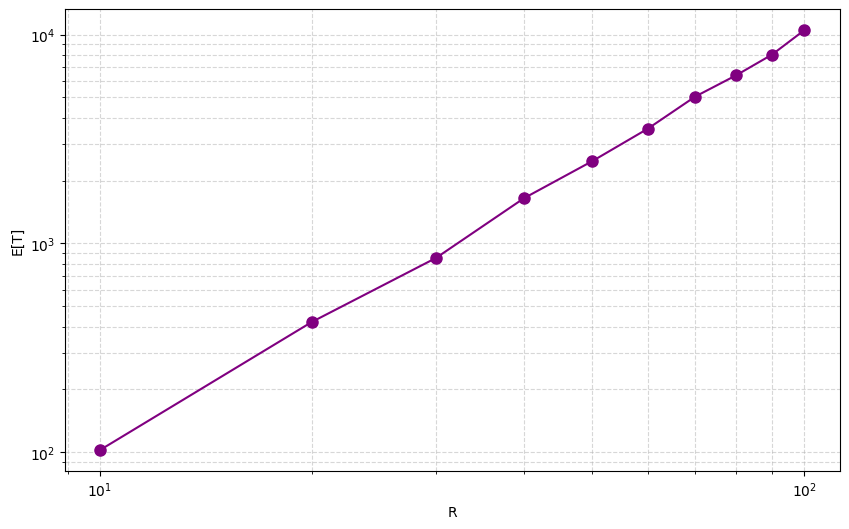

In [51]:
plt.figure(figsize=(10, 6))
plt.loglog(R_vals, mean_times, marker='o', linestyle='-', color='purple', markersize=8)

plt.xlabel('R')
plt.ylabel('E[T]')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

Yπολογίζουμε και την κλίση του γραφήματος

Από το διάγραμμα σε λογαριθμική κλίμακα, παρατηρούμε ότι σχηματίζεται μια  ευθεία γραμμή. Υπολογίζουμε την κλίση της αριθμητικά:

In [52]:
slope, intercept = np.polyfit(np.log10(R_vals), np.log10(mean_times), 1)

In [53]:
print(f"Slope in log-log diagram of E[T] vs R is : {slope:.2f}")

Slope in log-log diagram of E[T] vs R is : 2.00


Άρα ισχύει ότι log(E[T]) ≈2⋅log(R)+c , δηλαδή Ε[Τ] ~ R^2. Έτσι, συμπεραίνουμε ότι ο αναμενόμενος χρόνος διαφυγής της αλυσίδας από έναν δίσκο ακτίνας R δεν αυξάνεται γραμμικά, αλλά ανάλογα με το τετράγωνο της ακτίνας. Διαισθητικά θα μπρούσαμε να το εξηγήσουμε με τον εξής τρόπο:

Η αλυσίδα μας καθώς κινείται στον χρόνο αλλάζει κατεύθυνση τυχαία και είναι πολύ πιθανό να μην κινείται ευθεία, καθώς προχωρά σε βήματα στον Z^2, με ισοπίθανες πιθανότητες αυτά να είναι οριζόντια (μπρος-πίσω) ή κάθετα (πάνω-κάτω). Έτσι, «ξοδεύει» τεράστιο μέρος του χρόνου της διαγράφοντας  τροχιές γύρω από την ίδια μικρή περιοχή που βρίσκεται μέσα στον δίσκο ακτίνας R. Για αυτό, αναμένουμε ο χρόνος διαφυγής της από αυτόν να μην μεταβάλλεται αναλογικά με την ακτίνα του αλλά πιο απότομα, όπως είναι η τετραγωνική σχέση -> R^2.